# 03 — Embedding Visualisation

Compare cell embeddings:
- Raw marker space (baseline)
- Transformer model
- Mamba model

All visualised via UMAP, coloured by cell-type label.

**Prerequisites:**
1. `python scripts/prepare_data.py`  — processes and caches the dataset
2. `python scripts/make_splits.py`   — creates `split_manifest.json`
3. At least one completed experiment in `outputs/` with `embeddings/val_downstream_embeddings.npy`
   (run `scripts/train_model.py` + `scripts/evaluate_model.py`)

Steps 1–2 can be skipped: the notebook will load via PyCytoData and create an in-memory split if the files are missing.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()   # MambaC2S/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import LabelEncoder

from src.data.loader import load_levine32, load_processed
from src.data.preprocessing import preprocess_from_config
from src.data.splits import load_manifest, apply_splits, make_splits
from src.evaluation.metrics import compute_embedding_metrics, compute_umap
from src.utils.config import load_config

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
print('Project root:', PROJECT_ROOT)

Project root: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/MambaC2S


In [2]:
cfg = load_config(PROJECT_ROOT / 'configs' / 'base.yaml')

DATA_DIR     = PROJECT_ROOT / cfg['dataset']['data_dir']
OUTPUTS_DIR  = PROJECT_ROOT / cfg['output']['output_dir']
DATASET_NAME = cfg['dataset']['dataset_name']
LABEL_COL    = cfg['dataset']['label_col']
PREP_CFG     = cfg['preprocessing']
KNN_K        = cfg['evaluation']['knn_k']
SEED         = cfg['seed']

print(f'Outputs dir: {OUTPUTS_DIR}')

Outputs dir: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/MambaC2S/outputs


## Load Data and Splits

In [3]:
processed_path = DATA_DIR / f'{DATASET_NAME}_processed.h5ad'
manifest_path  = DATA_DIR / 'split_manifest.json'

# --- Load or build processed DataFrame ---
if processed_path.exists():
    print(f'Loading pre-processed data from {processed_path} ...')
    df = load_processed(processed_path, label_col=LABEL_COL)
else:
    print('Pre-processed file not found — loading via PyCytoData ...')
    df_raw = load_levine32(force_download=True)
    df, _  = preprocess_from_config(df_raw, PREP_CFG)

# --- Load or create splits ---
if manifest_path.exists():
    splits    = load_manifest(manifest_path)
    split_dfs = apply_splits(df, splits)
else:
    print('No split_manifest.json — building in-memory splits (run make_splits.py to persist).')
    sp     = cfg['splits']
    splits = make_splits(
        df,
        labeled_train=sp['labeled_train'],
        labeled_val=sp['labeled_val'],
        labeled_test=sp['labeled_test'],
        unlabeled_train=sp['unlabeled_train'],
        unlabeled_val=sp['unlabeled_val'],
        seed=SEED,
    )
    split_dfs = apply_splits(df, splits)

val_df = split_dfs['val_downstream']
labels = val_df[LABEL_COL].tolist()

non_marker = {LABEL_COL, 'cell_id'}
marker_cols = [
    c for c in val_df.columns
    if c not in non_marker
    and not c.endswith('_rank')
    and not c.endswith('_bin')
]

print(f'\nval_downstream : {len(val_df):,} cells  |  markers: {len(marker_cols)}  |  cell types: {val_df[LABEL_COL].nunique()}')

Pre-processed file not found — loading via PyCytoData ...


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/PyCytoData/data.py:15: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fcsparser/api.py:490: UserWarning: The default channel names (defined by the $PnS parameter in the FCS file) were not unique. To avoid problems in downstream analysis, the channel names have been switched to the alternate channel names defined in the FCS file. To avoid seeing this warning message, explicitly instruct the FCS parser to use the alternate channel names by specifying the channel_naming parameter.
  warnings.warn(msg)


No split_manifest.json — building in-memory splits (run make_splits.py to persist).

val_downstream : 20,837 cells  |  markers: 32  |  cell types: 14


## 1. Raw Marker Space UMAP (Baseline)

In [4]:
marker_embs = val_df[marker_cols].values.astype('float32')
print(f'Computing UMAP on raw marker space ({marker_embs.shape}) ...')

marker_umap = compute_umap(
    marker_embs,
    n_neighbors=cfg['evaluation']['n_umap_neighbors'],
    min_dist=cfg['evaluation']['umap_min_dist'],
    seed=SEED,
)
print('Done.')

Computing UMAP on raw marker space ((20837, 32)) ...


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done.


## 2. Find Trained Model Experiments

In [5]:
def find_experiment(outputs_dir: Path, model_type: str, tokenization: str):
    """Return most recent experiment dir that has saved embeddings."""
    if not outputs_dir.exists():
        return None
    matches = [
        d for d in sorted(outputs_dir.iterdir())
        if d.is_dir()
        and d.name.startswith(f'{model_type}_{tokenization}')
        and (d / 'embeddings' / 'val_downstream_embeddings.npy').exists()
    ]
    return matches[-1] if matches else None

transformer_dir = find_experiment(OUTPUTS_DIR, 'transformer', 'rank_only')
mamba_dir       = find_experiment(OUTPUTS_DIR, 'mamba',       'rank_only')

print(f'Transformer : {transformer_dir or "not found — run train+evaluate first"}')
print(f'Mamba       : {mamba_dir       or "not found — run train+evaluate first"}')

Transformer : not found — run train+evaluate first
Mamba       : not found — run train+evaluate first


In [6]:
model_embeddings = {}
model_umaps      = {}

for label, exp_dir in [('Transformer', transformer_dir), ('Mamba', mamba_dir)]:
    if exp_dir is None:
        print(f'{label}: skipping (no completed experiment found).')
        continue

    emb_path  = exp_dir / 'embeddings' / 'val_downstream_embeddings.npy'
    umap_path = exp_dir / 'embeddings' / 'val_downstream_umap.npy'

    model_embeddings[label] = np.load(emb_path)
    print(f'{label}: loaded embeddings {model_embeddings[label].shape} from {exp_dir.name}')

    if umap_path.exists():
        model_umaps[label] = np.load(umap_path)
        print(f'  → pre-computed UMAP loaded.')
    else:
        print(f'  → computing UMAP ...')
        model_umaps[label] = compute_umap(
            model_embeddings[label],
            n_neighbors=cfg['evaluation']['n_umap_neighbors'],
            min_dist=cfg['evaluation']['umap_min_dist'],
            seed=SEED,
        )

Transformer: skipping (no completed experiment found).
Mamba: skipping (no completed experiment found).


## 3. Side-by-Side UMAP Comparison

/var/folders/sm/c5y90hdx37s36m0309zwd4zm0000gn/T/ipykernel_30725/2579148526.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', n)
/var/folders/sm/c5y90hdx37s36m0309zwd4zm0000gn/T/ipykernel_30725/2579148526.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', n)


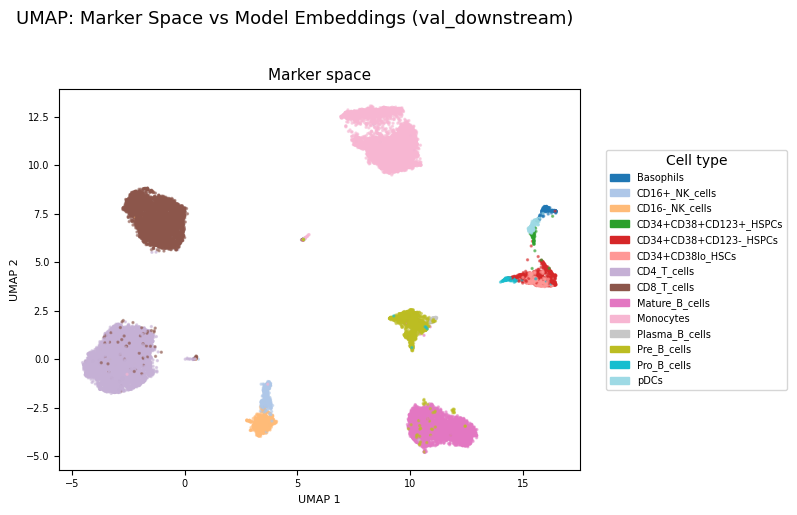

In [7]:
def plot_umap(coords, labels, title, ax):
    le = LabelEncoder()
    ids = le.fit_transform(labels)
    n   = len(le.classes_)
    cmap = plt.cm.get_cmap('tab20', n)
    ax.scatter(coords[:, 0], coords[:, 1], c=ids, cmap=cmap, s=2, alpha=0.5, vmin=0, vmax=n - 1)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('UMAP 1', fontsize=8)
    ax.set_ylabel('UMAP 2', fontsize=8)
    ax.tick_params(labelsize=7)
    return le.classes_

panels    = [('Marker space', marker_umap)] + list(model_umaps.items())
n_panels  = len(panels)

fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5))
if n_panels == 1:
    axes = [axes]

all_classes = None
for ax, (title, coords) in zip(axes, panels):
    all_classes = plot_umap(coords, labels, title, ax)

if all_classes is not None:
    le2  = LabelEncoder().fit(labels)
    n    = len(le2.classes_)
    cmap = plt.cm.get_cmap('tab20', n)
    handles = [mpatches.Patch(color=cmap(i), label=c) for i, c in enumerate(le2.classes_)]
    fig.legend(handles=handles, bbox_to_anchor=(1.01, 0.5), loc='center left',
               fontsize=7, title='Cell type')

fig.suptitle('UMAP: Marker Space vs Model Embeddings (val_downstream)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Quantitative Metric Comparison

In [8]:
rows = []

m = compute_embedding_metrics(marker_embs, labels, knn_k=KNN_K, seed=SEED)
rows.append({'Model': 'Marker space (baseline)', **m})

for name, embs in model_embeddings.items():
    m = compute_embedding_metrics(embs, labels, knn_k=KNN_K, seed=SEED)
    rows.append({'Model': name, **m})

table = pd.DataFrame(rows).set_index('Model')
print(table.to_string(float_format=lambda x: f'{x:.4f}'))
table.style.highlight_max(color='lightgreen', axis=0)

TypeError: only length-1 arrays can be converted to Python scalars

## 5. Tokenisation Ablation (Transformer, all schemes)

In [9]:
ablation_rows = []
for scheme in ('rank_only', 'strength_only', 'hybrid'):
    exp = find_experiment(OUTPUTS_DIR, 'transformer', scheme)
    if exp is None:
        ablation_rows.append({'Model': f'transformer_{scheme}', 'ARI': None, 'NMI': None, 'knn_purity': None})
        continue
    metrics_path = exp / 'metrics' / 'downstream.json'
    if metrics_path.exists():
        with open(metrics_path) as f:
            ablation_rows.append({'Model': f'transformer_{scheme}', **json.load(f)})
    else:
        ablation_rows.append({'Model': f'transformer_{scheme}', 'ARI': None, 'NMI': None, 'knn_purity': None})

abl_df = pd.DataFrame(ablation_rows).set_index('Model')
print('Tokenisation ablation (Transformer):')
print(abl_df.to_string())

Tokenisation ablation (Transformer):
                            ARI   NMI knn_purity
Model                                           
transformer_rank_only      None  None       None
transformer_strength_only  None  None       None
transformer_hybrid         None  None       None
